### 과대적합과 과소적합
#### 과대적합(overfitting)
* 훈련데이터에만 잘 맞고 테스트데이터에는 낮은 정답률이 나오는 경우

#### 과소적합(underfitting)
* 훈련이 제대로 이루어지지 않아 테스트 데이터보다 훈련데이터의 정답률이 낮은 경우
* 훈련, 테스트데이터 모두 정답률이 낮은 경우
* 훈련데이터의 개수가 적을 경우

---

### 스케일링
* 수치형 데이터들의 값의 범위가 클 경우 사용한다.(연산 속도 증가)
    - 예를 들어 주식의 가격을 생각했을 경우 100원의 1%와 100000원의 1%를 계산하고자 한다면 같은 1%연산이지만 숫자가 클 경우 연산속도에 영향을 미치게 된다.
* 서로 다른 변수의 값 범위를 일정한 수준으로 맞추고자 하는 경우
* 대표적 스케일링 클래스는 StandardScaler, MinMaxScaler이 있다
* 사용 이유
    - 연산속도를 올릴 수 있다
    - 확률을 높일 수 있다
    - 과대, 과소적합을 조금은 해결할 수 있다
* 참고
    - 이상치가 있을 경우 범위의 차이가 커지게 되므로 이상치는 제거해야 한다
    - RandomForest는 따로 스케일링 할 필요가 없다.(tree계열은 따로 스케일 할 필요가 없다)

#### StandardScaler(label값은 스케일 하지 않는다)
* 사이킷런에서 서포트벡터머신, 선형회귀, 로지스틱 회귀에 적용하는 것이 예측 성능 향상에 중요한 요소가 된다.
* 각 특성의 평균을 0, 편차를 1에 가깝게 변경하여 정규분포로 만드는 것이다

#### MinMaxScaler(label값은 스케일 하지 않는다)
* 모든 특성이 정확하게 0과 1사이에 위치하도록 데이터를 변경
* k-means, k-nearest neighbor등의 알고리즘에 좋은 성능을 보인다

In [3]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [4]:
movie = {'daum':[2,4,6,8,10], "naver":[1,2,3,4,5]}
mv = pd.DataFrame(movie)
mv

,daum,naver
0,2,1
1,4,2
2,6,3
3,8,4
4,10,5


In [5]:
min_max_scaler = MinMaxScaler()
tr = min_max_scaler.fit_transform(mv)
pd.DataFrame(tr, columns=['daum', 'naver'])

,daum,naver
0,0.00,0.00
1,0.25,0.25
2,0.50,0.50
3,0.75,0.75
4,1.00,1.00


In [8]:
mv.describe()

,daum,naver
count,5.000000,5.000000
mean,6.000000,3.000000
std,3.162278,1.581139
min,2.000000,1.000000
25%,4.000000,2.000000
50%,6.000000,3.000000
75%,8.000000,4.000000
max,10.000000,5.000000


In [9]:
standard_scaler = StandardScaler()
scaler = standard_scaler.fit_transform(mv)
scaler
df_sc = pd.DataFrame(scaler, columns=['daum','naver'])
df_sc

,daum,naver
0,-1.414214,-1.414214
1,-0.707107,-0.707107
2,0.000000,0.000000
3,0.707107,0.707107
4,1.414214,1.414214


In [10]:
df_sc.describe()

,daum,naver
count,5.000000,5.000000
mean,0.000000,0.000000
std,1.118034,1.118034
min,-1.414214,-1.414214
25%,-0.707107,-0.707107
50%,0.000000,0.000000
75%,0.707107,0.707107
max,1.414214,1.414214


In [11]:
df = pd.read_csv("../data_set/5.스케일링/bank_train_clean.csv")
df.head(3)

,age,duration,campaign,pdays,previous,y
0,58,261,1,-1,0,0
1,44,151,1,-1,0,0
2,33,76,1,-1,0,0


In [12]:
df.columns

Index(['age', 'duration', 'campaign', 'pdays', 'previous', 'y'], dtype='object')

In [14]:
f = ['age', 'duration', 'campaign', 'pdays', 'previous']
label = 'y'
X, y = df[f], df[label]

In [15]:
X.head(1)

,age,duration,campaign,pdays,previous
0,58,261,1,-1,0


In [16]:
X.shape, y.shape

((45211, 5), (45211,))

In [17]:
from sklearn.model_selection import train_test_split

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

In [19]:
X_train.shape, X_test.shape

((31647, 5), (13564, 5))

In [20]:
from sklearn.ensemble import RandomForestClassifier

In [22]:
rfc = RandomForestClassifier()
rfc.fit(X_train, y_train)
print("학습 데이터 score : ", rfc.score(X_train, y_train))
print("test 데이터 score : ", rfc.score(X_test, y_test))
f"과적합 확인 : {rfc.score(X_train, y_train) - rfc.score(X_test, y_test)}"

학습 데이터 score :  0.9921951527790944
test 데이터 score :  0.8759215570628134


'과적합 확인 : 0.11627359571628104'

In [23]:
X_train.head(1)

,age,duration,campaign,pdays,previous
43595,32,211,2,196,7


In [25]:
scaler = StandardScaler()
scaler.fit(X_train)

X_train_scaler = scaler.transform(X_train)
X_test_scaler = scaler.transform(X_test)

X_test_scaler

array([[ 1.4229858 , -0.60095764, -0.24588605, -0.4123123 , -0.23557718],
       [-0.46048935,  1.79436336, -0.56179852, -0.4123123 , -0.23557718],
       [ 0.19872695, -0.66317377,  1.64958875, -0.4123123 , -0.23557718],
       ...,
       [-1.0255319 , -0.47652538, -0.56179852, -0.4123123 , -0.23557718],
       [-1.49640068,  1.2383067 , -0.56179852,  0.5552176 ,  0.16938268],
       [-1.6847482 , -0.55040704,  0.07002641, -0.4123123 , -0.23557718]],
      shape=(13564, 5))

In [26]:
rfc.fit(X_train_scaler, y_train)
print("학습 데이터 score : ", rfc.score(X_train_scaler, y_train))
print("test 데이터 score : ", rfc.score(X_test_scaler, y_test))
f"과적합 확인 : {rfc.score(X_train_scaler, y_train) - rfc.score(X_test_scaler, y_test)}"

학습 데이터 score :  0.9922583499225835
test 데이터 score :  0.8761427307578885


'과적합 확인 : 0.11611561916469504'

In [27]:
scaler = MinMaxScaler()
scaler.fit(X_train)
X_train_scaler = scaler.transform(X_train)
X_test_scaler = scaler.transform(X_test)

rfc.fit(X_train_scaler, y_train)

print("학습 데이터 score : ", rfc.score(X_train_scaler, y_train))
print("test 데이터 score : ", rfc.score(X_test_scaler, y_test))
f"과적합 확인 : {rfc.score(X_train_scaler, y_train) - rfc.score(X_test_scaler, y_test)}"

학습 데이터 score :  0.9921003570638607
test 데이터 score :  0.8746682394573873


'과적합 확인 : 0.11743211760647343'

### 상관관계
* 특정 변수들 끼리의 상관관계가 높은 값을 제거하면 과대적합을 줄일 수 있다

In [28]:
df.head(1)

,age,duration,campaign,pdays,previous,y
0,58,261,1,-1,0,0


In [29]:
df.corr()

,age,duration,campaign,pdays,previous,y
age,1.000000,-0.004648,0.004760,-0.023758,0.001288,0.025155
duration,-0.004648,1.000000,-0.084570,-0.001565,0.001203,0.394521
campaign,0.004760,-0.084570,1.000000,-0.088628,-0.032855,-0.073172
pdays,-0.023758,-0.001565,-0.088628,1.000000,0.454820,0.103621
previous,0.001288,0.001203,-0.032855,0.454820,1.000000,0.093236
y,0.025155,0.394521,-0.073172,0.103621,0.093236,1.000000


In [30]:
import seaborn as sns

<Axes: >

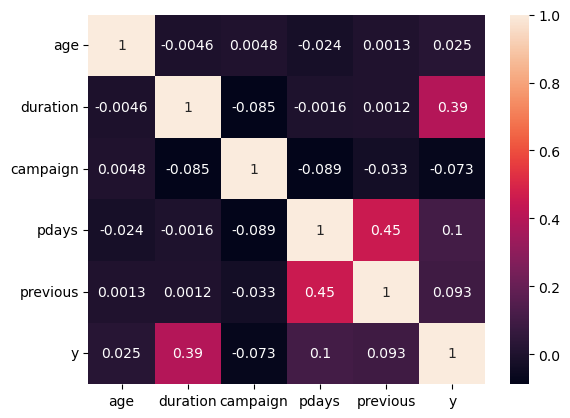

In [31]:
sns.heatmap(df.corr(), annot=True)

In [32]:
df.columns

Index(['age', 'duration', 'campaign', 'pdays', 'previous', 'y'], dtype='object')

In [33]:
f = ['age', 'campaign', 'pdays', 'previous']
laber = 'y'
X, y = df[f], df[label]

In [34]:
scaler = StandardScaler()
scaler.fit(X)
X_scaler = scaler.transform(X)
X_scaler

array([[ 1.60696496, -0.56935064, -0.41145311, -0.25194037],
       [ 0.28852927, -0.56935064, -0.41145311, -0.25194037],
       [-0.74738448, -0.56935064, -0.41145311, -0.25194037],
       ...,
       [ 2.92540065,  0.72181052,  1.43618859,  1.05047333],
       [ 1.51279098,  0.39902023, -0.41145311, -0.25194037],
       [-0.37068857, -0.24656035,  1.4761376 ,  4.52357654]],
      shape=(45211, 4))

In [35]:
X_train, X_test, y_train, y_test = train_test_split(X_scaler, y, test_size=0.3)

In [36]:
rfc = RandomForestClassifier()
rfc.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [37]:
print("train : ", rfc.score(X_train, y_train))
print("test : ", rfc.score(X_test, y_test))
print("과적합 확인 : ", rfc.score(X_train, y_train) - rfc.score(X_test, y_test))

train :  0.9263121306916927
test :  0.8782807431436155
과적합 확인 :  0.04803138754807723
